In [1]:
# Experiment 5 — Explainable AI & Fairness

## Aim

To apply Explainable AI (XAI) methods such as SHAP and LIME to interpret next-day AQI predictions and evaluate fairness considerations using Fairlearn.

## 1. Dataset & Model Selection

The processed Mumbai air-quality dataset and the final Tuned Random Forest model selected in Experiment 4 are used for explainability analysis.

SyntaxError: invalid syntax (624633711.py, line 5)

In [2]:
import pandas as pd
import numpy as np
import joblib

from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import shap
import lime
import lime.lime_tabular

from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference
)

import matplotlib.pyplot as plt

print("Libraries imported successfully.")
print("SHAP:", shap.__version__)
print("LIME: installed")

C:\Users\abhin\Downloads\air-quality-pipeline\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully.
SHAP: 0.49.1
LIME: installed


In [3]:
# Load processed dataset

DATA_PATH = "../data/processed/air_quality_cleaned.csv"

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2763, 22)


,city,date,aqi,pm25,pm10,no2,so2,co,o3,year,...,day_of_week,day_of_year,is_weekend,aqi_lag_1,aqi_lag_3,aqi_lag_7,target_aqi,aqi_rolling_mean_3,aqi_rolling_mean_7,aqi_rolling_std_7
0,Mumbai,2019-01-08,161,88.55,173.88,133.63,183.54,1.69,152.95,2019,...,1,8,0,146.0,178.0,194.0,154.0,172.000000,197.142857,38.429280
1,Mumbai,2019-01-09,154,84.70,166.32,127.82,175.56,1.62,146.30,2019,...,2,9,0,161.0,192.0,180.0,219.0,166.333333,192.428571,40.828328
2,Mumbai,2019-01-10,219,120.45,236.52,181.77,249.66,2.30,208.05,2019,...,3,10,0,154.0,146.0,267.0,212.0,153.666667,188.714286,43.257810
3,Mumbai,2019-01-11,212,116.60,228.96,175.96,241.68,2.23,201.40,2019,...,4,11,0,219.0,161.0,223.0,200.0,178.000000,181.857143,30.786515
4,Mumbai,2019-01-12,200,110.00,216.00,166.00,228.00,2.10,190.00,2019,...,5,12,1,212.0,154.0,178.0,206.0,195.000000,180.285714,28.534858


In [4]:
# Define target and features

target_column = "target_aqi"
excluded_columns = ["target_aqi", "date", "city"]

feature_columns = [
    column for column in df.columns
    if column not in excluded_columns
]

X = df[feature_columns]
y = df[target_column]

print("Number of features:", len(feature_columns))
print("Features:")
print(feature_columns)

Number of features: 19
Features:
['aqi', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'is_weekend', 'aqi_lag_1', 'aqi_lag_3', 'aqi_lag_7', 'aqi_rolling_mean_3', 'aqi_rolling_mean_7', 'aqi_rolling_std_7']


In [5]:
# Chronological 80:20 train-test split

split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2210
Testing samples: 553


In [6]:
# Load final Tuned Random Forest model

MODEL_PATH = "../models/final_aqi_random_forest.pkl"

final_model = joblib.load(MODEL_PATH)

print("Final model loaded successfully.")
print("Model:", type(final_model).__name__)

Final model loaded successfully.
Model: RandomForestRegressor


In [7]:
# Verify final model performance

test_predictions = final_model.predict(X_test)

mae = mean_absolute_error(y_test, test_predictions)
rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
r2 = r2_score(y_test, test_predictions)

print("Final Model Performance")
print("=" * 40)
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

Final Model Performance
MAE : 26.1019
RMSE: 35.3005
R²  : 0.5873


In [ ]:
## 2. Explainability with SHAP

SHAP (SHapley Additive exPlanations) is used to explain how individual features contribute to the model predictions.

A TreeExplainer is used because the final model is a Random Forest. Both global feature importance and feature-level relationships are examined.

In [8]:
# Create SHAP TreeExplainer

explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X_test)

print("SHAP values generated successfully.")
print("SHAP values shape:", np.array(shap_values).shape)

SHAP values generated successfully.
SHAP values shape: (553, 19)


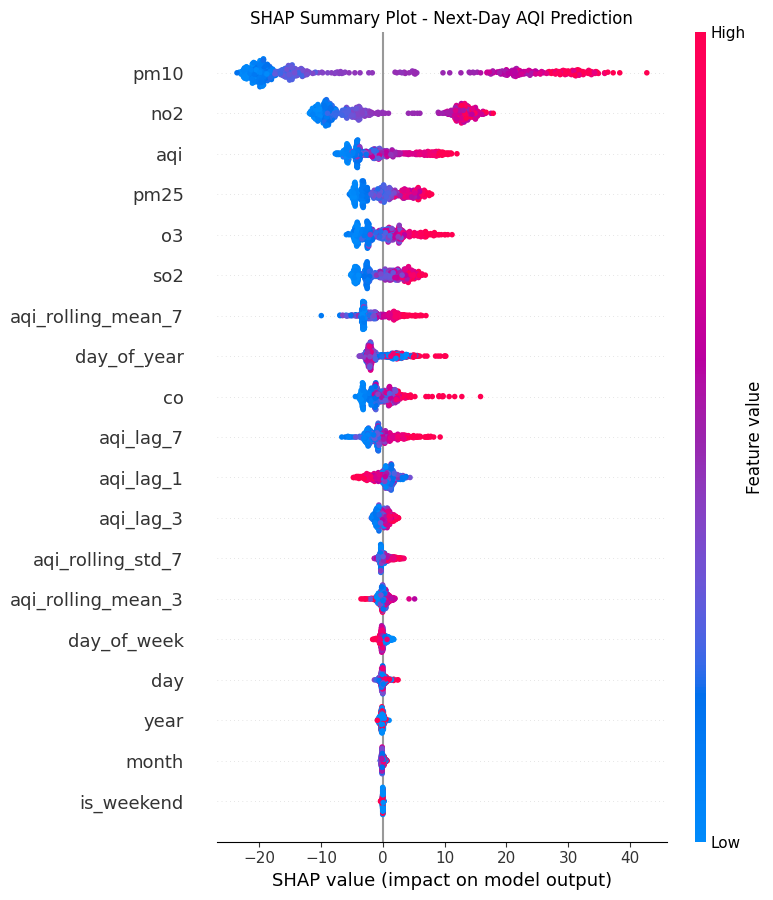

In [9]:
# SHAP summary plot

plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Summary Plot - Next-Day AQI Prediction")
plt.tight_layout()
plt.show()

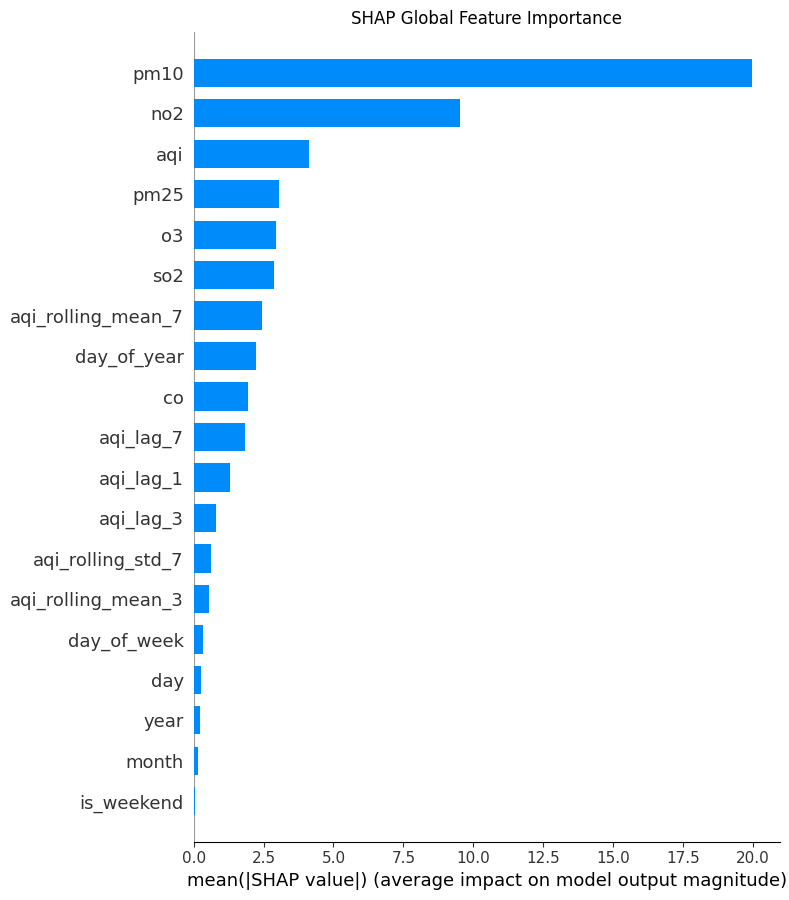

In [10]:
# SHAP global feature importance

plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title("SHAP Global Feature Importance")
plt.tight_layout()
plt.show()

In [11]:
# Calculate mean absolute SHAP importance

shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_Absolute_SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

display(shap_importance.round(4))

,Feature,Mean_Absolute_SHAP
0,pm10,19.9678
1,no2,9.5326
2,aqi,4.1372
3,pm25,3.0693
4,o3,2.9446
5,so2,2.8829
6,aqi_rolling_mean_7,2.4482
7,day_of_year,2.2207
8,co,1.9375
9,aqi_lag_7,1.8304


In [ ]:
### SHAP Interpretation

SHAP analysis was performed on the 553 observations in the chronological test set using a TreeExplainer for the final Random Forest model.

The global feature-importance analysis showed that PM10 was the most influential feature, with a mean absolute SHAP value of 19.9678, followed by NO₂ (9.5326) and AQI (4.1372). PM2.5, O₃, SO₂, and the 7-day rolling AQI mean also made notable contributions.

The SHAP summary plot indicates that higher PM10 values generally produce positive SHAP values, meaning they tend to increase the model's predicted next-day AQI, while lower PM10 values tend to decrease the prediction. Similar positive relationships can be observed for several major pollutant variables.

The historical AQI features also contributed to the predictions, particularly `aqi_rolling_mean_7`, `aqi_lag_7`, and `aqi_lag_1`. This indicates that the model uses both current pollutant conditions and recent AQI history when forecasting next-day AQI.

Overall, SHAP provides model-level interpretability by showing which features have the greatest influence on the Random Forest predictions and the direction in which feature values affect individual predictions.

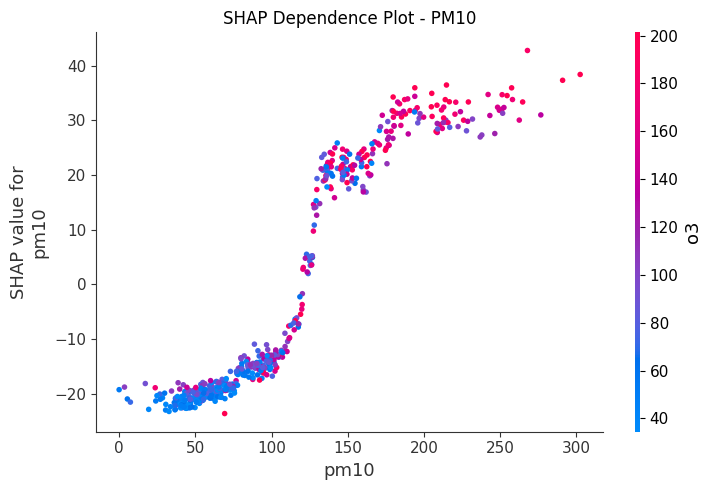

In [12]:
# SHAP dependence plot for PM10

shap.dependence_plot(
    "pm10",
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Dependence Plot - PM10")
plt.tight_layout()
plt.show()

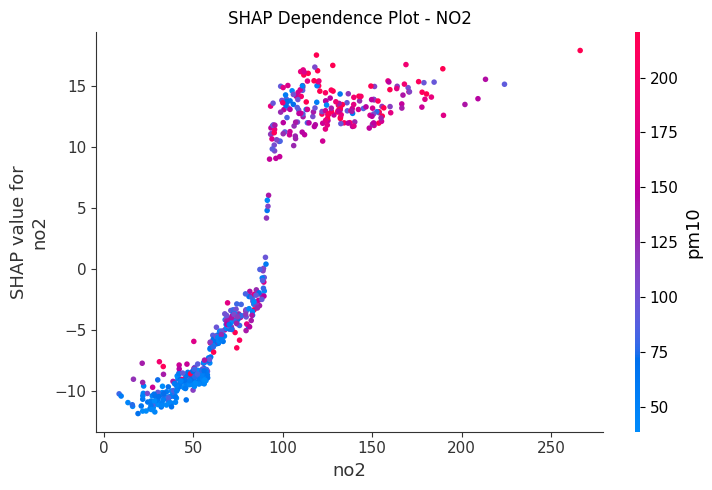

In [13]:
# SHAP dependence plot for NO2

shap.dependence_plot(
    "no2",
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Dependence Plot - NO2")
plt.tight_layout()
plt.show()

In [ ]:
## 3. Explainability with LIME

LIME (Local Interpretable Model-agnostic Explanations) is used to explain individual model predictions.

Unlike SHAP, which provides both global and local explanations, this analysis focuses on individual test observations to identify which features contributed most strongly to a specific next-day AQI prediction.

In [14]:
# Create LIME tabular explainer

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    mode="regression",
    discretize_continuous=True,
    random_state=42
)

print("LIME explainer created successfully.")

LIME explainer created successfully.


In [15]:
# Select an individual test observation

sample_index = 0
sample = X_test.iloc[sample_index].values

actual_aqi = y_test.iloc[sample_index]
predicted_aqi = final_model.predict(
    X_test.iloc[[sample_index]]
)[0]

print("Actual next-day AQI:", actual_aqi)
print("Predicted next-day AQI:", round(predicted_aqi, 2))

Actual next-day AQI: 170.0
Predicted next-day AQI: 149.67


In [16]:
# Generate LIME explanation

lime_explanation = lime_explainer.explain_instance(
    sample,
    final_model.predict,
    num_features=10
)

lime_results = pd.DataFrame(
    lime_explanation.as_list(),
    columns=["Feature", "Contribution"]
)

display(lime_results)

C:\Users\abhin\Downloads\air-quality-pipeline\.venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


,Feature,Contribution
0,no2 > 123.67,12.336145
1,aqi > 150.00,10.104096
2,aqi_rolling_mean_7 > 152.11,9.107493
3,97.20 < pm10 <= 162.00,7.676622
4,o3 > 141.55,7.084205
5,pm25 > 82.36,5.976823
6,day_of_year <= 89.25,4.273900
7,aqi_lag_1 > 150.00,-3.737459
8,aqi_lag_3 > 150.00,2.482979
9,102.60 < so2 <= 169.86,1.733803


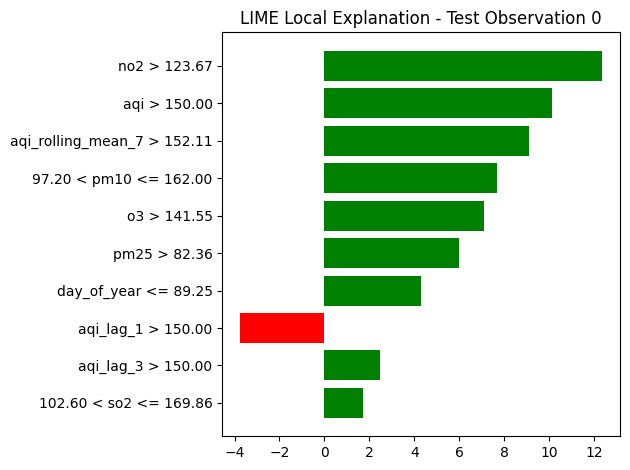

In [17]:
# Display LIME local explanation

fig = lime_explanation.as_pyplot_figure()

plt.title("LIME Local Explanation - Test Observation 0")
plt.tight_layout()
plt.show()

In [18]:
# Save LIME explanation

lime_explanation.save_to_file(
    "../reports/lime_explanation_sample_0.html"
)

print("LIME explanation saved successfully.")

LIME explanation saved successfully.


In [ ]:
### LIME Interpretation

LIME was used to explain an individual test-set prediction. For the selected test observation, the actual next-day AQI was 170.0 while the model predicted 149.67.

The largest positive local contribution was from `no2 > 123.67`, followed by the current AQI, the 7-day rolling AQI mean, PM10, O₃, and PM2.5. These features increased the local prediction. In contrast, `aqi_lag_1 > 150` produced a negative contribution and therefore pushed the prediction downward for this particular observation.

The LIME explanation demonstrates that individual predictions can be influenced by a different combination of features than the global feature-importance pattern identified by SHAP. SHAP identified PM10 as the most influential feature globally, whereas LIME identified NO₂ as the largest contributor for this particular prediction.

In [ ]:
## 4. Fairness Audit with Fairlearn

The dataset does not contain demographic sensitive attributes such as gender or race. Therefore, such attributes were not artificially created for the fairness analysis.

As an exploratory subgroup audit, `is_weekend` is used as a grouping variable to examine whether model prediction errors differ between weekday and weekend observations. This should not be interpreted as a protected-attribute fairness assessment.

Because the task is regression rather than binary classification, demographic parity difference and equalized odds difference are not directly appropriate for the AQI prediction target. Instead, Fairlearn's `MetricFrame` is used to compare regression performance across the available subgroups.

In [19]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Use the original test-set grouping variable
sensitive_features = df["is_weekend"].iloc[split_index:].reset_index(drop=True)

# Reset indices for consistency
y_test_fair = y_test.reset_index(drop=True)
test_predictions_fair = pd.Series(test_predictions).reset_index(drop=True)

print("Fairness grouping variable: is_weekend")
print(sensitive_features.value_counts())

Fairness grouping variable: is_weekend
is_weekend
0    395
1    158
Name: count, dtype: int64


In [20]:
# Define group-wise MAE

metric_frame_mae = MetricFrame(
    metrics=mean_absolute_error,
    y_true=y_test_fair,
    y_pred=test_predictions_fair,
    sensitive_features=sensitive_features
)

print("MAE by subgroup:")
display(metric_frame_mae.by_group)

MAE by subgroup:


is_weekend
0    25.440744
1    27.754922
Name: mean_absolute_error, dtype: float64

In [21]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

metric_frame_rmse = MetricFrame(
    metrics=rmse,
    y_true=y_test_fair,
    y_pred=test_predictions_fair,
    sensitive_features=sensitive_features
)

print("RMSE by subgroup:")
display(metric_frame_rmse.by_group)

RMSE by subgroup:


is_weekend
0    34.186578
1    37.942566
Name: rmse, dtype: float64

In [22]:
# Calculate subgroup performance differences

mae_difference = (
    metric_frame_mae.by_group.max()
    - metric_frame_mae.by_group.min()
)

rmse_difference = (
    metric_frame_rmse.by_group.max()
    - metric_frame_rmse.by_group.min()
)

print("MAE difference between groups:", round(mae_difference, 4))
print("RMSE difference between groups:", round(rmse_difference, 4))

MAE difference between groups: 2.3142
RMSE difference between groups: 3.756


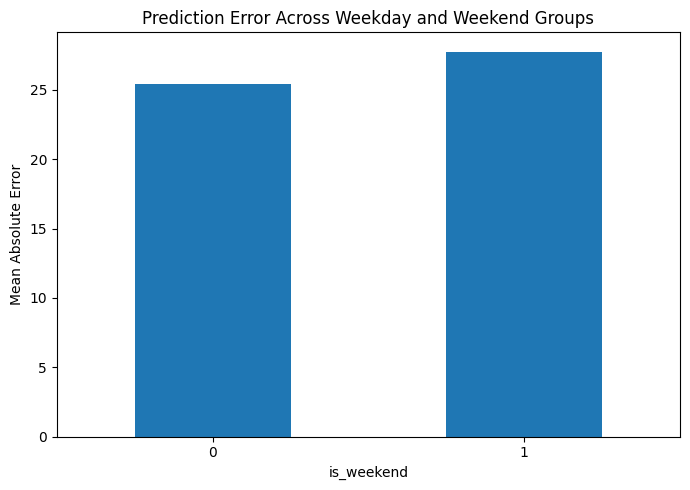

In [23]:
# Visualize MAE by subgroup

plt.figure(figsize=(7, 5))

metric_frame_mae.by_group.plot(
    kind="bar"
)

plt.ylabel("Mean Absolute Error")
plt.xlabel("is_weekend")
plt.title("Prediction Error Across Weekday and Weekend Groups")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

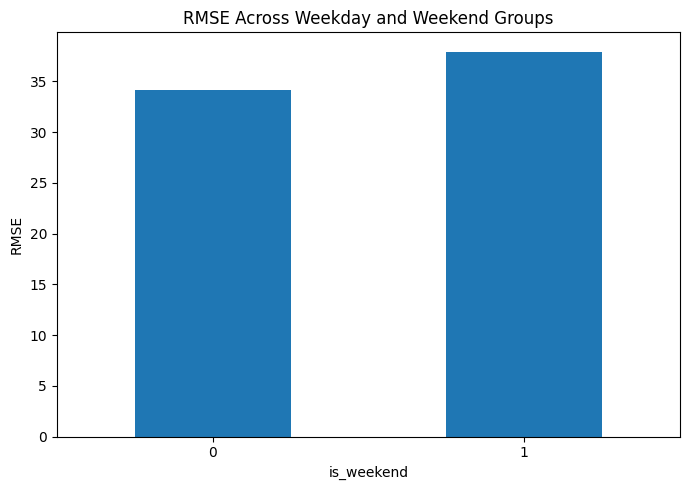

In [24]:
# Visualize RMSE by subgroup

plt.figure(figsize=(7, 5))

metric_frame_rmse.by_group.plot(
    kind="bar"
)

plt.ylabel("RMSE")
plt.xlabel("is_weekend")
plt.title("RMSE Across Weekday and Weekend Groups")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
# Create fairness audit summary

fairness_report = pd.DataFrame({
    "Group": ["Weekday", "Weekend"],
    "Observations": [395, 158],
    "MAE": [
        metric_frame_mae.by_group.loc[0],
        metric_frame_mae.by_group.loc[1]
    ],
    "RMSE": [
        metric_frame_rmse.by_group.loc[0],
        metric_frame_rmse.by_group.loc[1]
    ]
})

display(fairness_report.round(4))

,Group,Observations,MAE,RMSE
0,Weekday,395,25.4407,34.1866
1,Weekend,158,27.7549,37.9426


In [26]:
# Save fairness audit report

fairness_report.to_csv(
    "../reports/fairness_audit_report.csv",
    index=False
)

print("Fairness audit report saved successfully.")

Fairness audit report saved successfully.
